In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement des données

In [2]:
data = pd.read_excel("../data/INRA2018_TablesFourrages_etude_prediction_20241121.xlsx", header=1)

In [3]:
data.head()

,No,Etat,Code INRA,Libellé 0,Libellé 1,Libellé 2,Libellé 3,Libellé 4,MS,UFL,...,GlyDI,AlaDI,TyrDI,C14:0,C16:0,C16:1,C18:0,C18:1,C18:2,C18:3
0,1,1,FV0010,FOURRAGES VERTS,"PRAIRIES PERMANENTES, PLAINE (NORMANDIE)",1er cycle,"15-25 avril, déprimage, ST = 172°C",NaN,15.5,1.07,...,6.94,6.87,4.13,1.0,15.68,1.4,2.30,4.04,16.34,54.50
1,2,1,FV0020,FOURRAGES VERTS,"PRAIRIES PERMANENTES, PLAINE (NORMANDIE)",1er cycle,"1-10 mai, pâturage, ST = 298°C",NaN,16.6,1.02,...,6.93,6.88,4.14,1.0,16.36,1.4,2.38,4.19,16.89,52.75
2,3,1,FV0030,FOURRAGES VERTS,"PRAIRIES PERMANENTES, PLAINE (NORMANDIE)",1er cycle,"15-25 mai, début épiaison, ST = 470°C",NaN,17.2,0.94,...,6.80,6.87,4.10,1.0,17.46,1.4,2.49,4.41,17.65,49.96
3,4,1,FV0040,FOURRAGES VERTS,"PRAIRIES PERMANENTES, PLAINE (NORMANDIE)",1er cycle,"1-10 juin, épiaison, ST = 685°C",NaN,20.2,0.84,...,6.81,6.88,4.11,1.0,18.22,1.4,2.56,4.54,18.12,48.04
4,5,1,FV0050,FOURRAGES VERTS,"PRAIRIES PERMANENTES, PLAINE (NORMANDIE)",1er cycle,"15-25 juin, floraison, ST = 903°C",NaN,19.2,0.74,...,6.81,6.89,4.12,1.0,18.79,1.4,2.61,4.63,18.46,46.59


# Fig.1 Répartition des données de fourrage

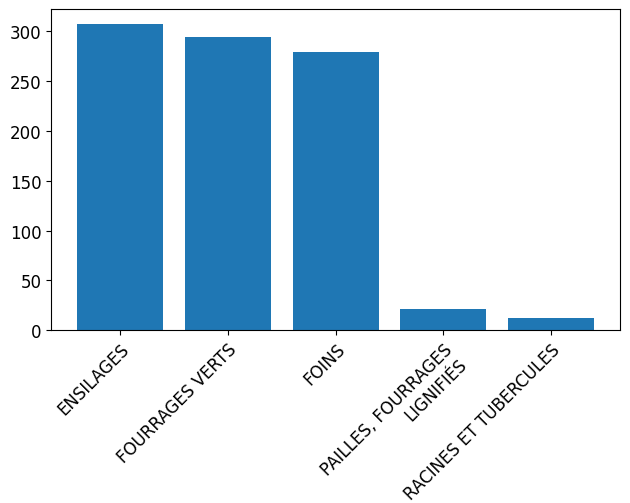

In [24]:
hist = data['Libellé 0'].value_counts()

plt.bar(hist.index,hist.values)
plt.xticks(ha='right',rotation=45,wrap=True, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

fig.savefig('fig1.png')

# Fig. 2 - Valeurs manquantes

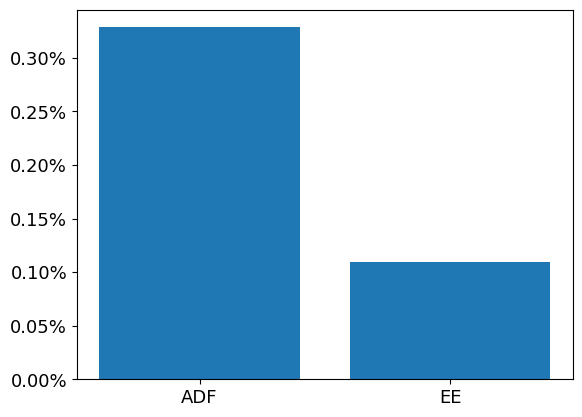

<Figure size 1500x1500 with 0 Axes>

In [25]:
from matplotlib import ticker

hist = data.isna().sum()/data.shape[0]
cols = ['ADF', 'EE']
hist = hist.loc[cols]


fig, ax = plt.subplots()
fig = plt.figure(figsize=(15,15))

ax.bar(hist.index, hist.values)

ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=2))
ax.tick_params(labelsize=13)


fig.savefig('fig2.png')

# Fig. 4 - Neural net

In [2]:
!pip install graphviz

In [4]:
import graphviz  # doctest: +NO_EXE
dot = graphviz.Digraph(comment='The Round Table')
dot  #doctest: +ELLIPSIS

In [20]:
!python3 dotnets.py | dot -Tpng > net.png

# Fig. 5 Embedder

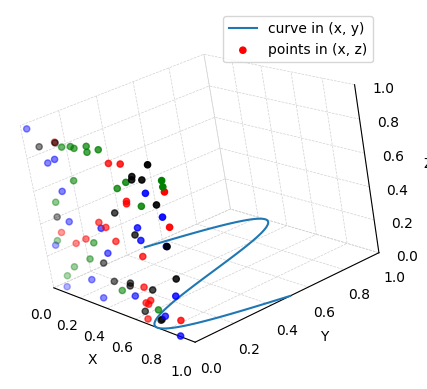

In [14]:
ax = plt.figure().add_subplot(projection='3d')

# Plot a sin curve using the x and y axes.
x = np.linspace(0, 1, 100)
y = np.sin(x * 2 * np.pi) / 2 + 0.5
ax.plot(x, y, zs=0, zdir='z', label='curve in (x, y)')

# Plot scatterplot data (20 2D points per colour) on the x and z axes.
colors = ('r', 'g', 'b', 'k')

# Fixing random state for reproducibility
np.random.seed(19680801)

x = np.random.sample(20 * len(colors))
y = np.random.sample(20 * len(colors))
c_list = []
for c in colors:
    c_list.extend([c] * 20)
# By using zdir='y', the y value of these points is fixed to the zs value 0
# and the (x, y) points are plotted on the x and z axes.
ax.scatter(x, y, zs=0, zdir='y', c=c_list, label='points in (x, z)')

# Make legend, set axes limits and labels
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')


for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo['axisline']['linewidth'] = 5
    axis._axinfo['axisline']['color'] = "d"
    axis._axinfo['grid']['linewidth'] = 0.5
    axis._axinfo['grid']['linestyle'] = "--"
    axis._axinfo['grid']['color'] = "#d1d1d1"
    axis._axinfo['tick']['inward_factor'] = 0.0
    axis._axinfo['tick']['outward_factor'] = 0.0
    axis.set_pane_color((1, 1, 1))

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20., azim=-35, roll=10)

plt.show()